<a href="https://colab.research.google.com/github/yentran31251022363-ship-it/final/blob/main/vnd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── Cài & import ──────────────────────────────────────────────
import os, glob, zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ================================================================
#  SỬA ĐƯỜNG DẪN NÀY cho đúng với file bạn upload lên Drive
# ================================================================
ZIP_PATH = '/content/drive/MyDrive/zip/archive.zip'
# ================================================================

EXTRACT_DIR = '/content/data'
os.makedirs(EXTRACT_DIR, exist_ok=True)

if os.path.exists(ZIP_PATH):
    print(f'📦 Đang giải nén ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('✅ Xong! Cấu trúc thư mục:')
    for root, dirs, files in os.walk(EXTRACT_DIR):
        depth = root.replace(EXTRACT_DIR, '').count(os.sep)
        if depth <= 2:
            indent = '  ' * depth
            print(f'{indent}{os.path.basename(root)}/')
else:
    print(f'❌ Không thấy file: {ZIP_PATH}')
    print('   → Kiểm tra lại tên file và đường dẫn trên Drive')

📦 Đang giải nén ...
✅ Xong! Cấu trúc thư mục:
data/
  dataset/
    020000/
    005000/
    002000/
    100000/
    000200/
    000000/
    500000/
    200000/
    000500/
    010000/
    001000/
    050000/


In [3]:
# Tự động tìm thư mục chứa các class ảnh
def find_dataset_root(base='/content/data'):
    best_dir, best_n = base, 0
    for root, dirs, files in os.walk(base):
        imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
        subdirs = [d for d in dirs if os.path.isdir(os.path.join(root, d))]
        if len(subdirs) > best_n:
            best_dir, best_n = root, len(subdirs)
    return best_dir

DATA_DIR = find_dataset_root()
classes  = sorted([c for c in os.listdir(DATA_DIR)
                   if os.path.isdir(os.path.join(DATA_DIR, c))])

print(f'📂 Data root  : {DATA_DIR}')
print(f'✅ {len(classes)} class : {classes}')

📂 Data root  : /content/data/dataset
✅ 12 class : ['000000', '000200', '000500', '001000', '002000', '005000', '010000', '020000', '050000', '100000', '200000', '500000']


      000000: 250 ảnh
      000200: 250 ảnh
      000500: 250 ảnh
      001000: 250 ảnh
      002000: 250 ảnh
      005000: 154 ảnh
      010000: 250 ảnh
      020000: 154 ảnh
      050000: 154 ảnh
      100000: 250 ảnh
      200000: 250 ảnh
      500000: 250 ảnh

Tổng: 2712 ảnh


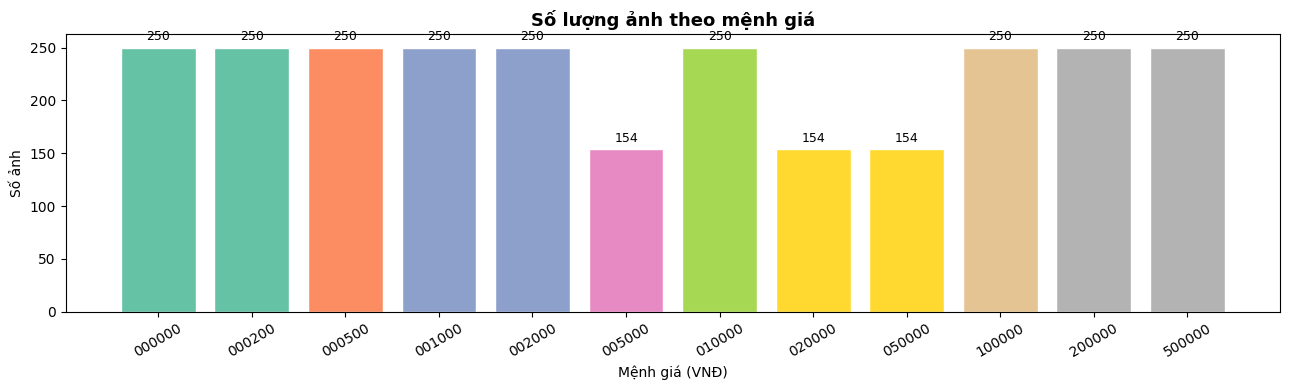

In [4]:
counts = {}
for c in classes:
    imgs = [p for p in glob.glob(os.path.join(DATA_DIR, c, '*'))
            if p.lower().endswith(('.jpg','.jpeg','.png'))]
    counts[c] = len(imgs)

for k,v in counts.items():
    print(f'  {k:>10}: {v} ảnh')
print(f'\nTổng: {sum(counts.values())} ảnh')

fig, ax = plt.subplots(figsize=(13,4))
bars = ax.bar(counts.keys(), counts.values(),
              color=plt.cm.Set2(np.linspace(0,1,len(classes))), edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Số lượng ảnh theo mệnh giá', fontsize=13, fontweight='bold')
ax.set_xlabel('Mệnh giá (VNĐ)'); ax.set_ylabel('Số ảnh')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

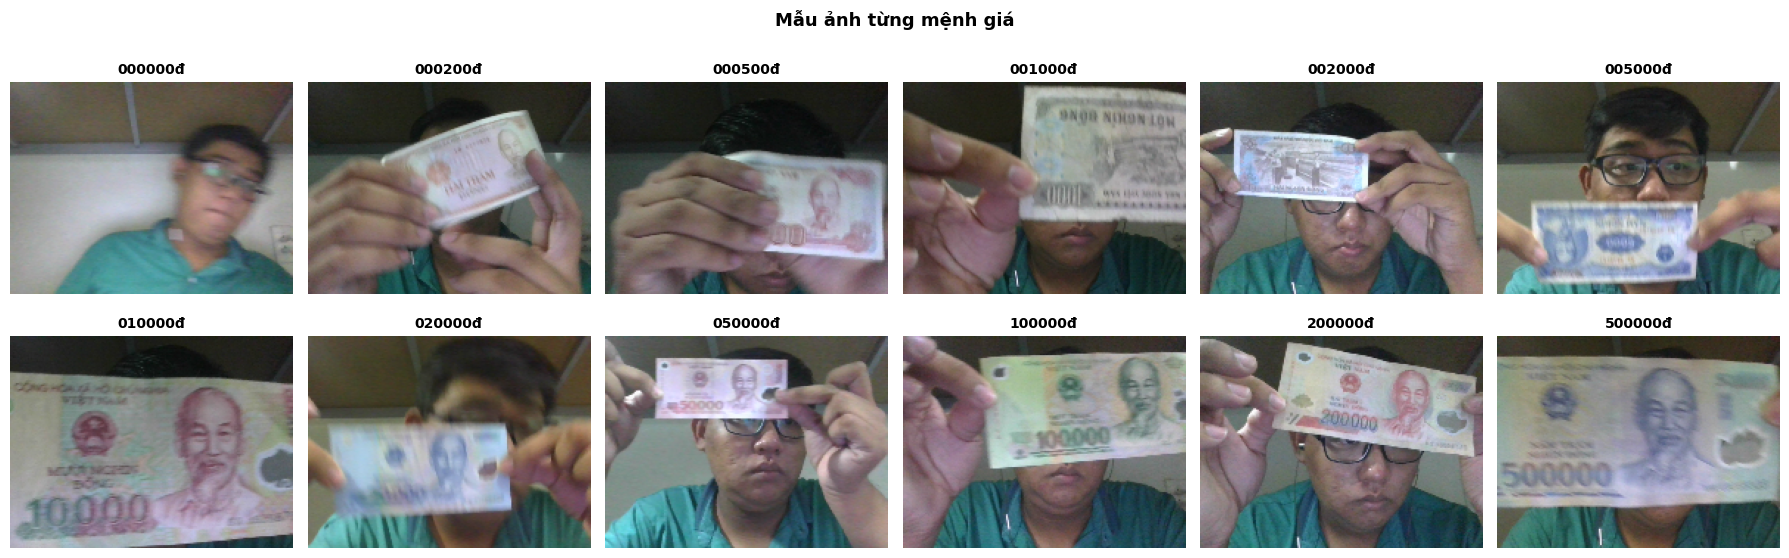

In [5]:
# Mẫu ảnh mỗi class
cols = 6; rows = (len(classes) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
axes = axes.flatten()
for i, cls in enumerate(classes):
    imgs = [p for p in glob.glob(os.path.join(DATA_DIR, cls, '*'))
            if p.lower().endswith(('.jpg','.jpeg','.png'))]
    if imgs:
        axes[i].imshow(Image.open(np.random.choice(imgs)).convert('RGB'))
        axes[i].set_title(f'{cls}đ', fontsize=10, fontweight='bold')
    axes[i].axis('off')
for j in range(len(classes), len(axes)): axes[j].axis('off')
plt.suptitle('Mẫu ảnh từng mệnh giá', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [6]:
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
SEED        = 42
NUM_CLASSES = len(classes)

train_gen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    shear_range=0.1, zoom_range=0.15, horizontal_flip=True,
    brightness_range=[0.8, 1.2], fill_mode='nearest'
).flow_from_directory(DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True)

val_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2
).flow_from_directory(DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False)

class_names = list(train_gen.class_indices.keys())
print(f'Train: {train_gen.samples} ảnh | Val: {val_gen.samples} ảnh')

Found 2172 images belonging to 12 classes.
Found 540 images belonging to 12 classes.
Train: 2172 ảnh | Val: 540 ảnh


In [7]:
def build_custom_cnn(input_shape, num_classes):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(32,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2,2), layers.Dropout(0.25),
        layers.Conv2D(64,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(64,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2,2), layers.Dropout(0.25),
        layers.Conv2D(128,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.Conv2D(128,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.MaxPooling2D(2,2), layers.Dropout(0.30),
        layers.Conv2D(256,(3,3),padding='same'), layers.BatchNormalization(), layers.Activation('relu'),
        layers.GlobalAveragePooling2D(), layers.Dropout(0.40),
        layers.Dense(512, activation='relu'), layers.BatchNormalization(), layers.Dropout(0.50),
        layers.Dense(num_classes, activation='softmax')
    ], name='CustomCNN')

def build_mobilenetv2(input_shape, num_classes):
    base = keras.applications.MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = False
    inp = keras.Input(shape=input_shape)
    x   = keras.applications.mobilenet_v2.preprocess_input(inp * 255.0)
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='MobileNetV2_Transfer'), base

# ── Chọn mô hình ──────────────────────────────────────
ACTIVE_MODEL = 'mobile'   # 'mobile' hoặc 'cnn'
# ──────────────────────────────────────────────────────
if ACTIVE_MODEL == 'mobile':
    model, base_model = build_mobilenetv2((*IMG_SIZE,3), NUM_CLASSES)
else:
    model = build_custom_cnn((*IMG_SIZE,3), NUM_CLASSES)
    base_model = None

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,590,028 (9.88 MB)

 Trainable params: 331,532 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [8]:
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('── Phase 1: Train classifier head (base frozen) ──')
history1 = model.fit(train_gen, epochs=35, validation_data=val_gen, callbacks=callbacks, verbose=1)

── Phase 1: Train classifier head (base frozen) ──
Epoch 1/35
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.4245 - loss: 2.0715
Epoch 1: val_accuracy improved from None to 0.59444, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 62s 598ms/step - accuracy: 0.5944 - loss: 1.3804 - val_accuracy: 0.5944 - val_loss: 1.2501 - learning_rate: 0.0010
Epoch 2/35
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.8309 - loss: 0.5432
Epoch 2: val_accuracy improved from 0.59444 to 0.73519, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 254ms/step - accuracy: 0.8195 - loss: 0.5525 - val_accuracy: 0.7352 - val_loss: 0.8051 - learning_rate: 0.0010
Epoch 3/35
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.8699 - loss: 0.4057
Epoch 3: val_accuracy did not improve from 0.73519
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 228ms/step

In [9]:
# Phase 2: Fine-tuning (MobileNetV2)
if ACTIVE_MODEL == 'mobile' and base_model is not None:
    print('\n── Phase 2: Fine-tune 30 layer cuối ──')
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    history2 = model.fit(train_gen, epochs=20, validation_data=val_gen, callbacks=callbacks, verbose=1)
    for k in history1.history:
        history1.history[k] += history2.history.get(k, [])

final_history = history1
print('✅ Training hoàn tất!')


── Phase 2: Fine-tune 30 layer cuối ──
Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.8153 - loss: 0.5517
Epoch 1: val_accuracy did not improve from 0.81296
68/68 ━━━━━━━━━━━━━━━━━━━━ 53s 503ms/step - accuracy: 0.8375 - loss: 0.4829 - val_accuracy: 0.7426 - val_loss: 0.9856 - learning_rate: 1.0000e-04
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9105 - loss: 0.2470
Epoch 2: val_accuracy did not improve from 0.81296
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 232ms/step - accuracy: 0.9277 - loss: 0.2114 - val_accuracy: 0.7481 - val_loss: 0.9720 - learning_rate: 1.0000e-04
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9511 - loss: 0.1474
Epoch 3: val_accuracy did not improve from 0.81296
68/68 ━━━━━━━━━━━━━━━━━━━━ 16s 231ms/step - accuracy: 0.9494 - loss: 0.1526 - val_accuracy: 0.7556 - val_loss: 1.0840 - learning_rate: 1.0000e-04
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9675 - loss: 0.1168
Epoch 4: ReduceLROnPlatea

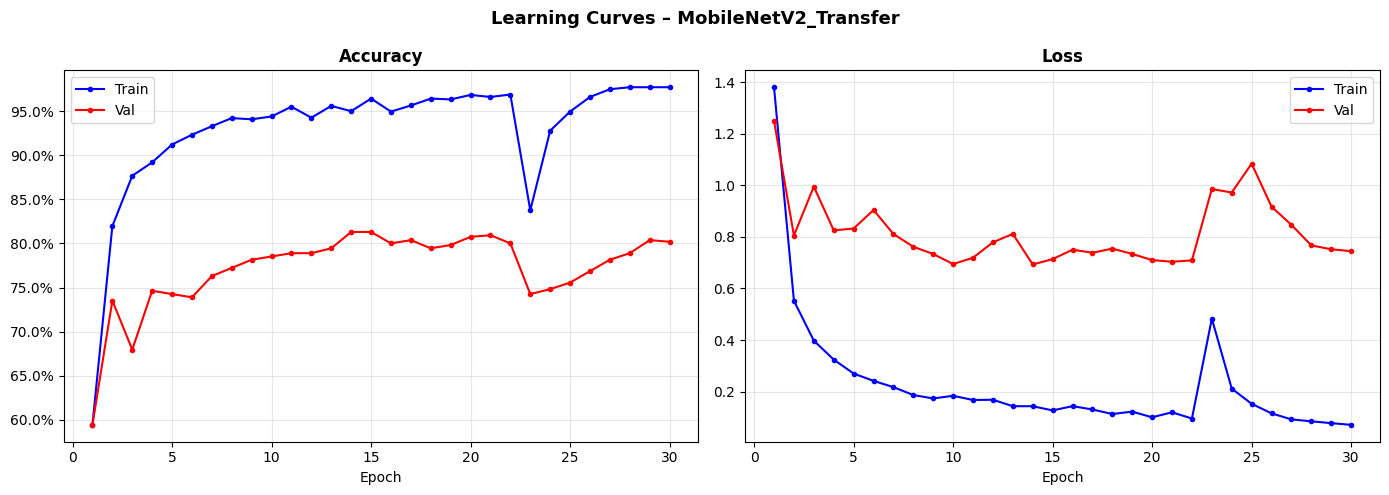

In [10]:
# Learning Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ep = range(1, len(final_history.history['accuracy'])+1)
ax1.plot(ep, final_history.history['accuracy'],     'b-o', ms=3, label='Train')
ax1.plot(ep, final_history.history['val_accuracy'], 'r-o', ms=3, label='Val')
ax1.set_title('Accuracy', fontweight='bold'); ax1.set_xlabel('Epoch')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, final_history.history['loss'],     'b-o', ms=3, label='Train')
ax2.plot(ep, final_history.history['val_loss'], 'r-o', ms=3, label='Val')
ax2.set_title('Loss', fontweight='bold'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle(f'Learning Curves – {model.name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 342ms/step


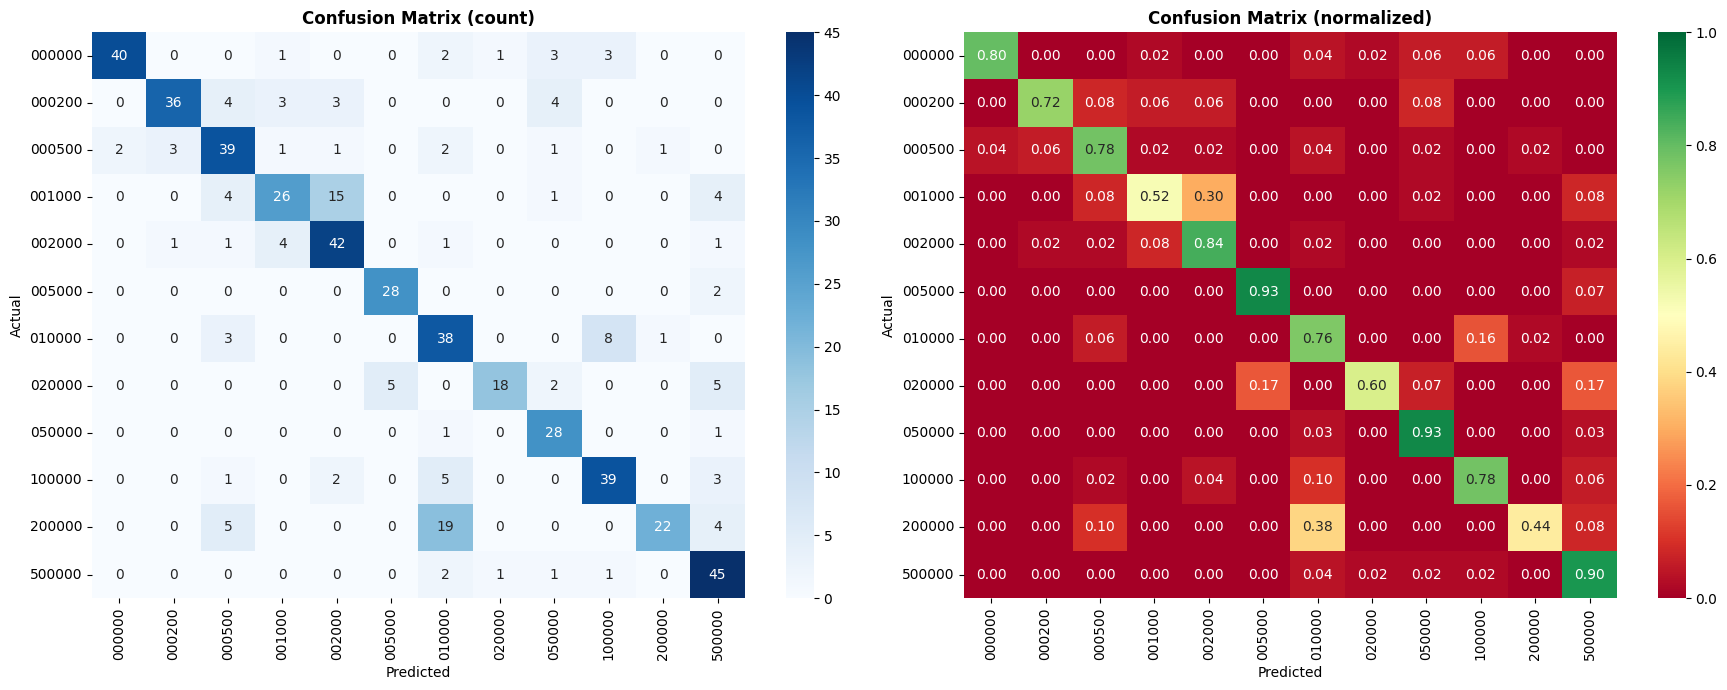

              precision    recall  f1-score   support

      000000       0.95      0.80      0.87        50
      000200       0.90      0.72      0.80        50
      000500       0.68      0.78      0.73        50
      001000       0.74      0.52      0.61        50
      002000       0.67      0.84      0.74        50
      005000       0.85      0.93      0.89        30
      010000       0.54      0.76      0.63        50
      020000       0.90      0.60      0.72        30
      050000       0.70      0.93      0.80        30
      100000       0.76      0.78      0.77        50
      200000       0.92      0.44      0.59        50
      500000       0.69      0.90      0.78        50

    accuracy                           0.74       540
   macro avg       0.78      0.75      0.75       540
weighted avg       0.77      0.74      0.74       540



In [11]:
# Confusion Matrix + Classification Report
val_gen.reset()
y_pred_prob = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_gen.classes

cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (count)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (normalized)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

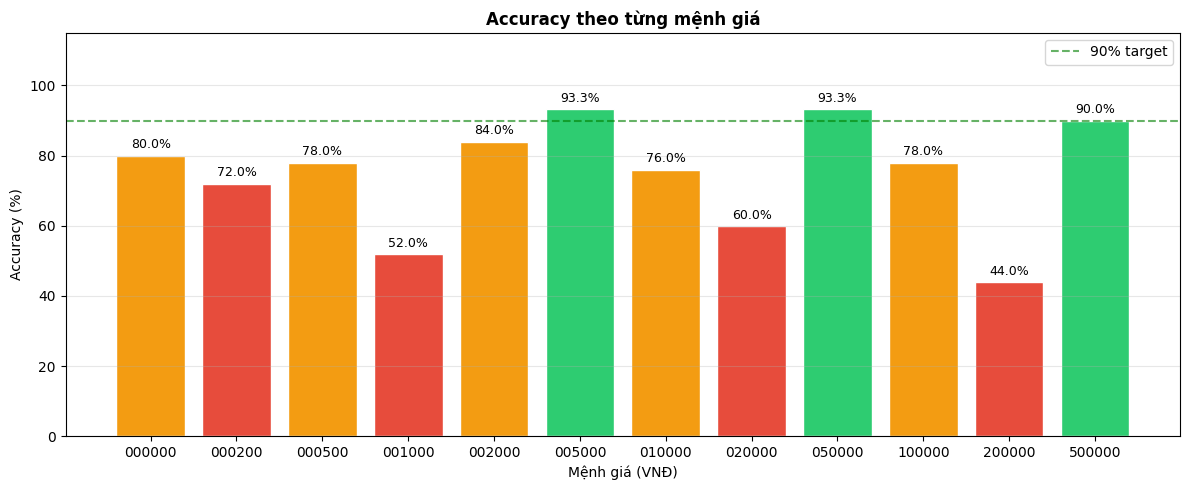

In [12]:
# Per-class Accuracy
per_class_acc = cm_norm.diagonal()
colors = ['#2ecc71' if a>=0.9 else '#f39c12' if a>=0.75 else '#e74c3c' for a in per_class_acc]
fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(class_names, per_class_acc*100, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.axhline(90, color='green', ls='--', alpha=0.6, label='90% target')
ax.set_ylim(0,115); ax.set_xlabel('Mệnh giá (VNĐ)'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy theo từng mệnh giá', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

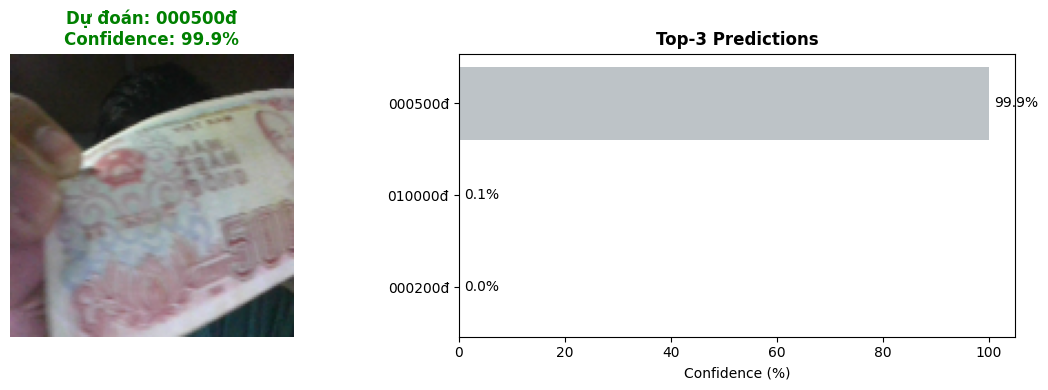

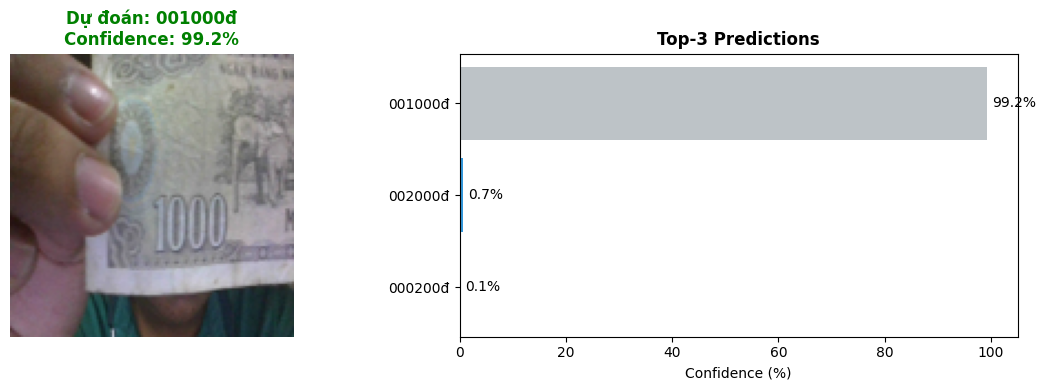

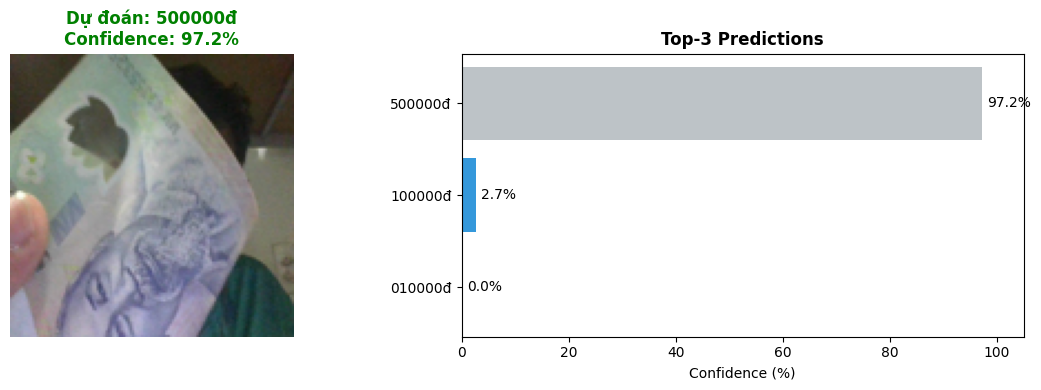

In [13]:
def predict_image(img_path):
    img  = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
    arr  = np.expand_dims(np.array(img)/255.0, axis=0)
    prob = model.predict(arr, verbose=0)[0]
    top3 = np.argsort(prob)[::-1][:3]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.imshow(img); ax1.axis('off')
    ax1.set_title(f'Dự đoán: {class_names[top3[0]]}đ\nConfidence: {prob[top3[0]]*100:.1f}%',
                  fontweight='bold', color='green', fontsize=12)
    labels = [f'{class_names[i]}đ' for i in top3]
    vals   = [prob[i]*100 for i in top3]
    ax2.barh(labels[::-1], vals[::-1], color=['#2ecc71','#3498db','#bdc3c7'])
    ax2.set_xlabel('Confidence (%)'); ax2.set_xlim(0,105)
    ax2.set_title('Top-3 Predictions', fontweight='bold')
    for i,(v,l) in enumerate(zip(vals[::-1],labels[::-1])):
        ax2.text(v+1, i, f'{v:.1f}%', va='center')
    plt.tight_layout(); plt.show()

# Demo 3 ảnh ngẫu nhiên từ dataset
sample_paths = []
for cls in classes:
    imgs = [p for p in glob.glob(os.path.join(DATA_DIR, cls, '*'))
            if p.lower().endswith(('.jpg','.jpeg','.png'))]
    if imgs: sample_paths.append(np.random.choice(imgs))

for path in np.random.choice(sample_paths, min(3,len(sample_paths)), replace=False):
    predict_image(path)


--- Nhấn 'Choose Files' để chọn ảnh cần nhận dạng ---


Saving 100000_81.png to 100000_81 (1).png


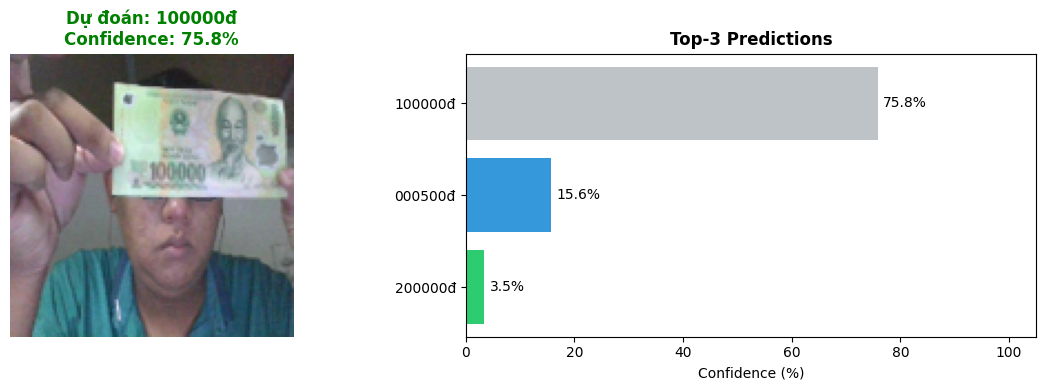


Bạn có muốn tiếp tục nhận dạng ảnh khác không? (y/n): y

--- Nhấn 'Choose Files' để chọn ảnh cần nhận dạng ---


Saving 500000_5.png to 500000_5 (2).png


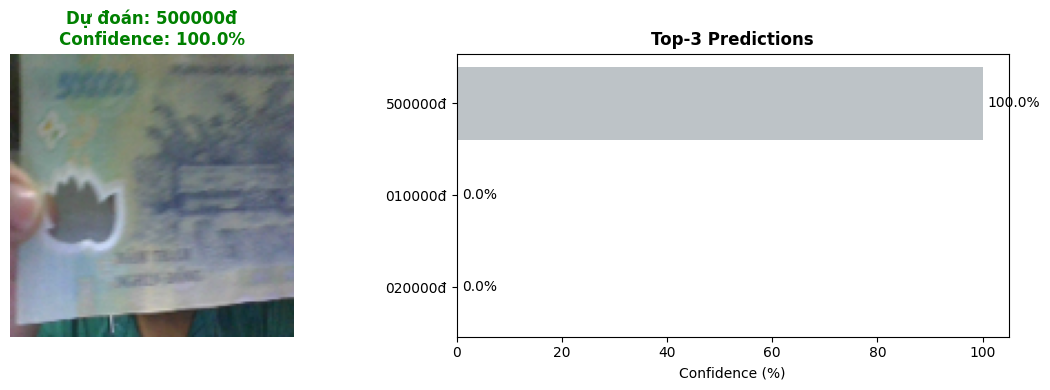


Bạn có muốn tiếp tục nhận dạng ảnh khác không? (y/n): y

--- Nhấn 'Choose Files' để chọn ảnh cần nhận dạng ---


Saving 200000_83.png to 200000_83.png


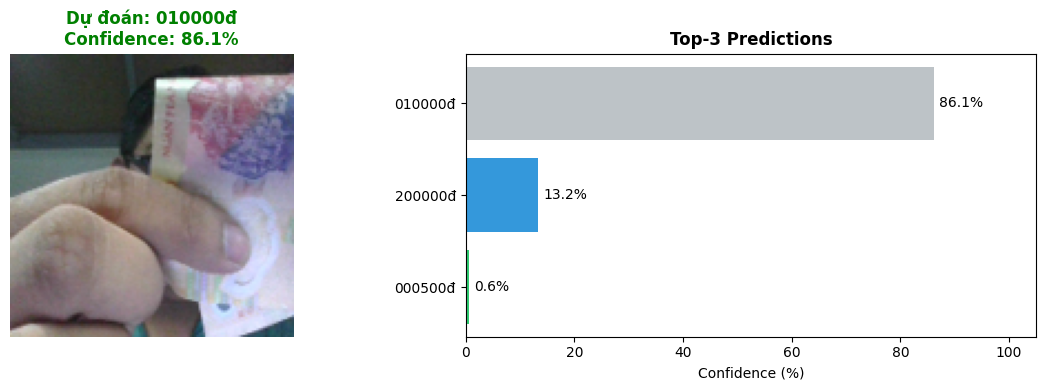


Bạn có muốn tiếp tục nhận dạng ảnh khác không? (y/n): y

--- Nhấn 'Choose Files' để chọn ảnh cần nhận dạng ---


Saving 200000_85.png to 200000_85.png


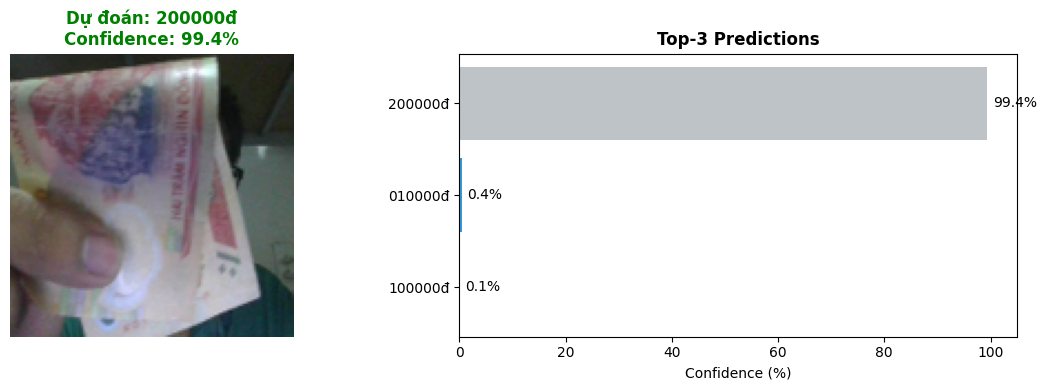


Bạn có muốn tiếp tục nhận dạng ảnh khác không? (y/n): y

--- Nhấn 'Choose Files' để chọn ảnh cần nhận dạng ---


Saving 020000_206.png to 020000_206 (1).png


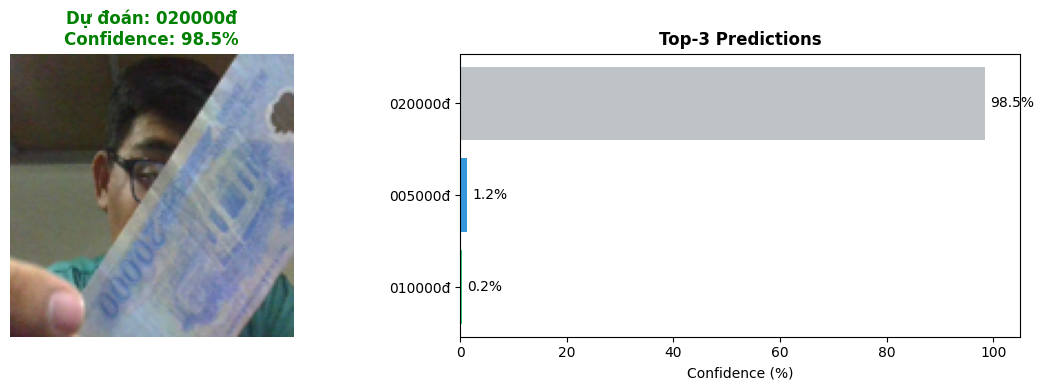


Bạn có muốn tiếp tục nhận dạng ảnh khác không? (y/n): y

--- Nhấn 'Choose Files' để chọn ảnh cần nhận dạng ---


Saving 005000_99.png to 005000_99.png


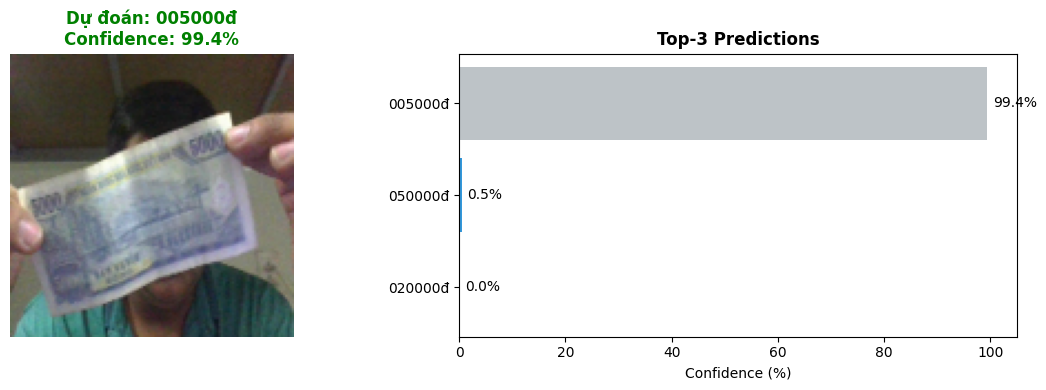


Bạn có muốn tiếp tục nhận dạng ảnh khác không? (y/n): y

--- Nhấn 'Choose Files' để chọn ảnh cần nhận dạng ---


Saving 002000_79.png to 002000_79.png


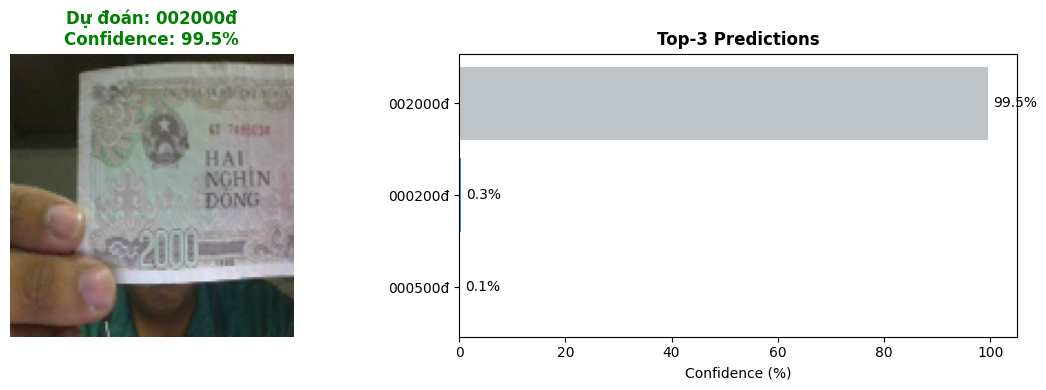


Bạn có muốn tiếp tục nhận dạng ảnh khác không? (y/n): n
Đã dừng chương trình nhận dạng.


In [22]:
# Upload ảnh từ máy để test
from google.colab import files

while True:
    print("\n--- Nhấn 'Choose Files' để chọn ảnh cần nhận dạng ---")
    uploaded_test = files.upload()

    # Kiểm tra xem người dùng có chọn ảnh nào không (nếu bấm Cancel ngay từ đầu)
    if not uploaded_test:
        print("Không có ảnh nào được chọn. Đã thoát.")
        break

    for fname in uploaded_test:
        with open(fname, 'wb') as f:
            f.write(uploaded_test[fname])

        # Gọi hàm dự đoán của bạn
        predict_image(fname)

    # Hỏi người dùng muốn tiếp tục hay dừng lại để đổi ảnh khác
    ans = input("\nBạn có muốn tiếp tục nhận dạng ảnh khác không? (y/n): ").strip().lower()
    if ans != 'y':
        print("Đã dừng chương trình nhận dạng.")
        break